## Fase 2: Análisis Exploratorio de Datos (EDA)

Dataset: Customer Personality Analysis

El objetivo de este análisis exploratorio es comprender la estructura del dataset, evaluar su calidad y detectar patrones relevantes en el comportamiento de los clientes. 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [11]:
## Para iniciar el análisis, se realizó una verificación de valores nulos con el fin de identificar posibles problemas de calidad en los datos.

missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Valores faltantes por columna:\n", missing_values[missing_values > 0])
print("\nPorcentaje de nulidad:\n", missing_percentage[missing_percentage > 0])

Valores faltantes por columna:
 Income    24
dtype: int64

Porcentaje de nulidad:
 Income    1.071429
dtype: float64


A partir de esta revisión se identifica que la única variable afectada es Income, 
con aproximadamente un 1.07% de valores faltantes. Aunque la magnitud es baja, 
esta variable tiene un papel importante en el análisis del comportamiento de consumo,
por lo que no puede ser ignorada.
#Dado que la distribución de los ingresos presenta asimetría y posibles valores extremos, 
se opta por realizar una imputación utilizando la mediana. Esta decisión permite mantener 
la consistencia de la variable sin verse afectada por outliers. Asimismo, se evita eliminar
registros para no perder información relevante en las demás variables.

## Detección de valores atípicos

Una vez tratados los valores faltantes, se procede a identificar valores atípicos en la variable Income, utilizando tanto métodos estadísticos como visuales.

Outliers detectados por IQR en Income: 8


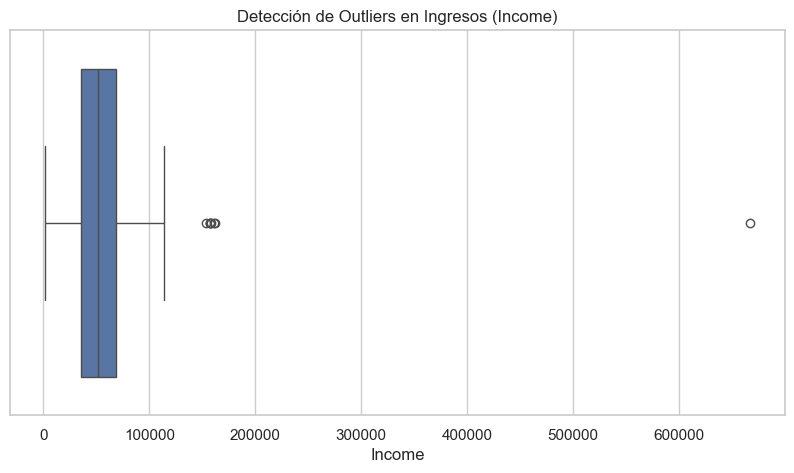

In [12]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = df[(df['Income'] < limite_inferior) | (df['Income'] > limite_superior)]
print(f"Outliers detectados por IQR en Income: {len(outliers_iqr)}")

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Income'])
plt.title('Detección de Outliers en Ingresos (Income)')
plt.show()

El análisis permite identificar la presencia de valores extremos significativamente alejados del comportamiento general. En particular, se observan ingresos que superan ampliamente los rangos esperados, incluso alcanzando cifras poco coherentes con el resto del dataset.

Debido a que este tipo de valores puede distorsionar análisis posteriores, especialmente técnicas como PCA que son sensibles a la escala, se establece un criterio de control. En este caso, los valores superiores a 200,000 serán tratados como atípicos severos y se considerarán para filtrado o ajuste en la fase de preparación de datos.

## Análisis de distribuciones y comportamiento univariado

Con el fin de comprender mejor las variables individuales, se construyó una nueva variable denominada Age a partir del año de nacimiento.

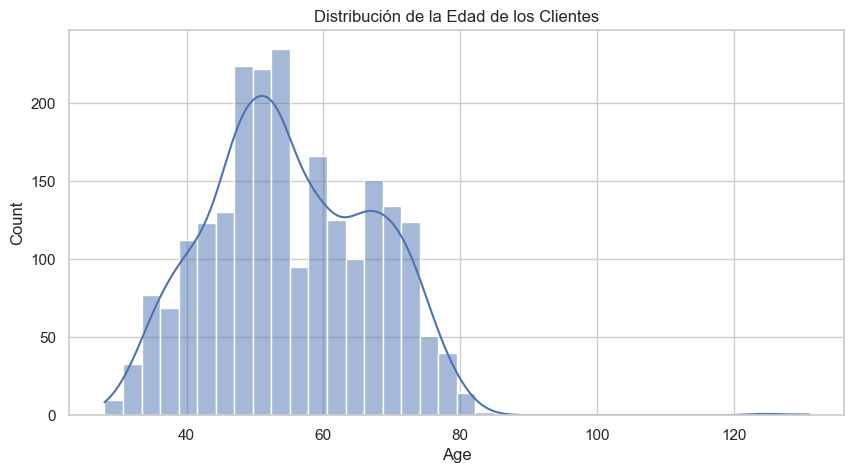

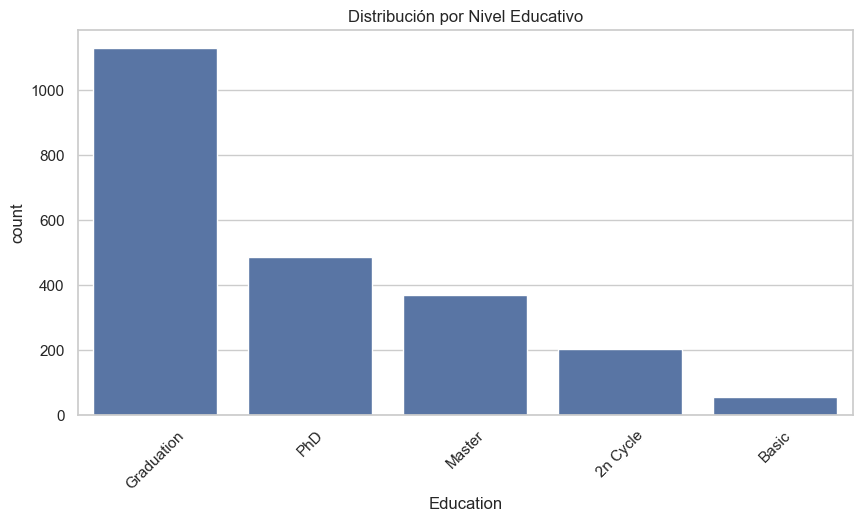

In [13]:
df['Age'] = 2024 - df['Year_Birth']

plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], kde=True)
plt.title('Distribución de la Edad de los Clientes')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Education', order=df['Education'].value_counts().index)
plt.title('Distribución por Nivel Educativo')
plt.xticks(rotation=45)
plt.show()

Se observa que el dataset presenta cierta homogeneidad en el nivel educativo, con predominancia del nivel "Graduation". En cuanto a las variables numéricas relacionadas con gasto, se identifican distribuciones con fuerte sesgo positivo, caracterizadas por una alta concentración de valores bajos y una cola larga hacia valores altos. 
Adicionalmente, se detectan inconsistencias en la variable Year_Birth, que generan edades poco realistas, lo que indica problemas de calidad que deben ser corregidos.

## Análisis multivariado y relaciones entre variables

Para analizar el comportamiento global de consumo, se construyó una variable agregada que representa el gasto total del cliente.

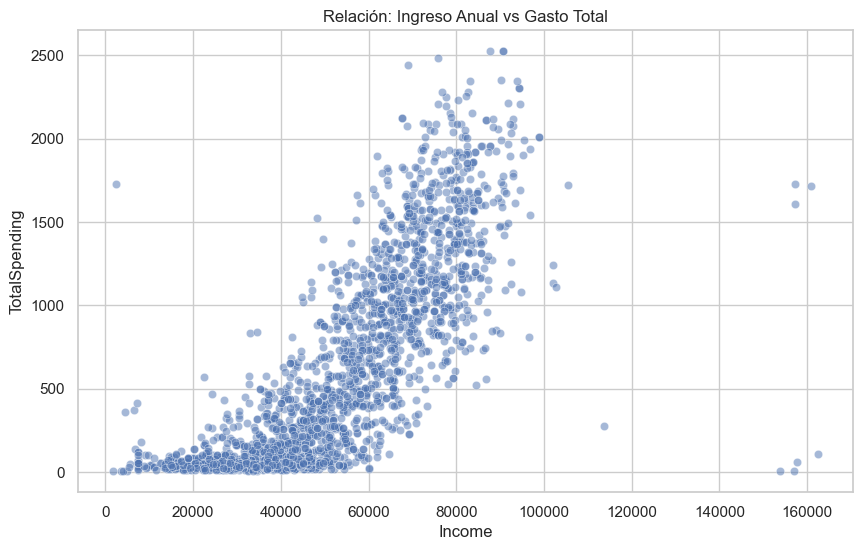

In [14]:
df['TotalSpending'] = df.filter(like='Mnt').sum(axis=1)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['Income'] < 200000], x='Income', y='TotalSpending', alpha=0.5)
plt.title('Relación: Ingreso Anual vs Gasto Total')
plt.show()

El mapa de calor muestra que las variables de gasto presentan alta correlación entre sí, lo que indica redundancia en la información y refuerza la necesidad de aplicar técnicas de reducción de dimensionalidad.

## Construcción de hipótesis

A partir de los patrones observados durante el análisis, es posible plantear algunas hipótesis iniciales que podrán ser evaluadas en fases posteriores. Se espera que el nivel educativo tenga una influencia directa en el consumo de productos premium, especialmente en categorías como vinos. De igual forma, se plantea que existe una relación positiva significativa entre el ingreso y el gasto en productos específicos como carnes.

Por otro lado, se considera que variables relacionadas con la composición del hogar, como la presencia de niños, pueden influir en el comportamiento de compra, particularmente en el uso de canales digitales.

## Insights principales

El análisis realizado permite identificar varios hallazgos relevantes. En primer lugar, se evidencia que el perfil predominante del dataset corresponde a clientes con nivel educativo medio-alto, lo que define una base relativamente homogénea. Asimismo, se detectan problemas de calidad en variables como Year_Birth, que generan edades no realistas y requieren depuración.

En términos de comportamiento, se confirma la existencia de una relación directa entre ingreso y gasto, aunque con indicios de saturación en niveles altos. También se observa que la presencia de hijos está asociada a cambios en los patrones de consumo, especialmente en la reducción del gasto en productos considerados no esenciales.

Finalmente, la alta correlación entre variables de gasto sugiere que el dataset contiene redundancia estructural, lo que valida el uso de técnicas como PCA en la siguiente fase para simplificar la representación de los datos sin perder información relevante.